<a href="https://colab.research.google.com/github/Visionary-DataWorks/DSPL-Project/blob/main/xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## processing


In [ ]:
#import functions
import pandas as pd
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [ ]:
data=pd.read_csv('/content/cleaned_train_data.csv')

In [ ]:
data.head()

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_category
0,10493832.0,Kelaniya,1209.60,756.00,5292.00,4
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4


In [ ]:
print(data.info())
print(data.isnull().sum)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 774148 entries, 0 to 774147
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Customer_ID       774146 non-null  float64
 1   outlet_city       774148 non-null  object 
 2   luxury_sales      774148 non-null  float64
 3   fresh_sales       774148 non-null  float64
 4   dry_sales         774148 non-null  float64
 5   cluster_category  774148 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 35.4+ MB
None
<bound method DataFrame.sum of         Customer_ID  outlet_city  luxury_sales  fresh_sales  dry_sales  \
0             False        False         False        False      False   
1             False        False         False        False      False   
2             False        False         False        False      False   
3             False        False         False        False      False   
4             False        False     

In [ ]:
print(data.columns)

Index(['Customer_ID', 'outlet_city', 'luxury_sales', 'fresh_sales',
       'dry_sales', 'cluster_category'],
      dtype='object')


In [ ]:
#Define Features (X)and Target (Y)
x = data.drop(columns=['cluster_category','Customer_ID']) #independent variables
y = data['cluster_category'] #Target variable

print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (774148, 4)
Target shape: (774148,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encoding for outlet city
le = LabelEncoder()
x['outlet_city'] = le.fit_transform(x['outlet_city'])

In [ ]:
#splitting data into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state= 42)

print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)

Training set size: (619318, 4)
Testing set size: (154830, 4)


In [ ]:
#check shape for whole dataset
print('Whole Data shape', data.shape)

Whole Data shape (774148, 6)


In [ ]:
from sklearn. preprocessing import RobustScaler

#initialize scaler()
scaler = RobustScaler()

#fit &transform training data, transform testing data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# Adjust target labels to start from 0
y_train = y_train - y_train.min()
y_test = y_test - y_test.min()


## XGB

In [ ]:
#create xgboost function
from xgboost import XGBClassifier
model = xgb.XGBClassifier(Use_label_encoder=False, eval_metric='logloss')
model.fit(x_train_scaled,y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:09:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "Use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(Use_label_encoder=False, base_score=None, booster=None,
              callbacks=None, colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Predictions
y_pred = model.predict(x_test_scaled)

In [ ]:
#To see the predicted values
print("Predicted Values: ", y_pred)

Predicted Values:  [1 1 0 ... 1 5 1]


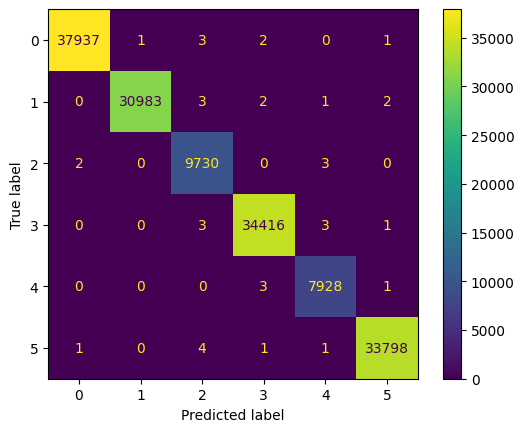

In [ ]:
# plot of the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
# Apply the function to find the correct predictions
accuracy=accuracy_score(y_test,y_pred)
# Display the accuracy
print ('The XGboost Model Accuracy:',accuracy)

The XGboost Model Accuracy: 0.9997545695278692


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37944
           1       1.00      1.00      1.00     30991
           2       1.00      1.00      1.00      9735
           3       1.00      1.00      1.00     34423
           4       1.00      1.00      1.00      7932
           5       1.00      1.00      1.00     33805

    accuracy                           1.00    154830
   macro avg       1.00      1.00      1.00    154830
weighted avg       1.00      1.00      1.00    154830



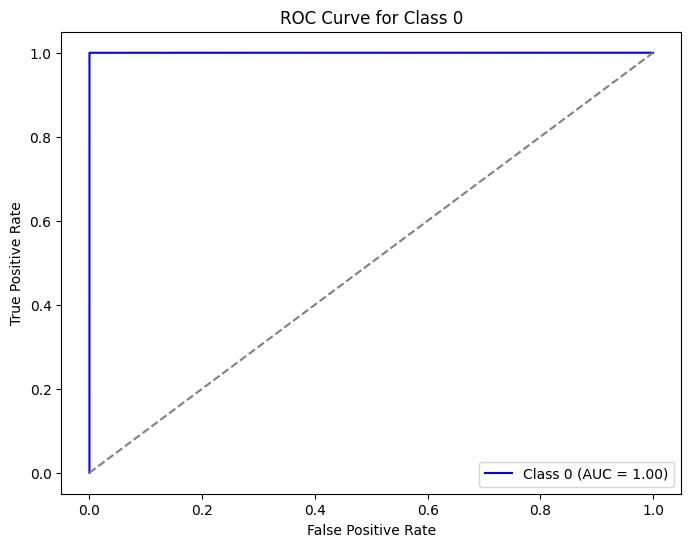

In [ ]:
#ROc CURVE
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import label_binarize

# Binarize the target variable for multi-class ROC curve
y_test_bin = label_binarize(y_test, classes=model.classes_)
n_classes = y_test_bin.shape[1]
yproba=model.predict_proba(x_test_scaled)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], yproba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), yproba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curve for a specific class (e.g., class 0)
plt.figure(figsize=(8, 6))
plt.plot(fpr[0], tpr[0], color='blue', label=f'Class 0 (AUC = {roc_auc[0]:.2f})')  # Change index for other classes
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Class 0')
plt.legend(loc='lower right')
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:09:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "Use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:09:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "Use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:09:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "Use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:10:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "Use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:10:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "Use_label_e

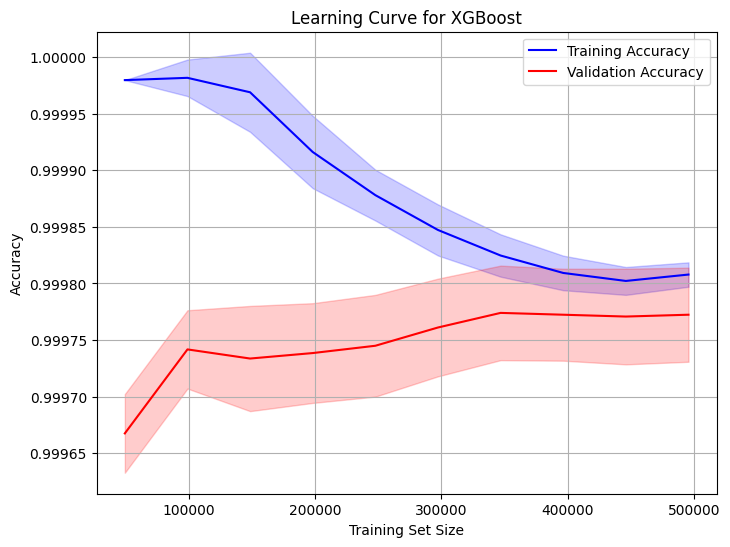

In [ ]:
#Learning curve
from sklearn.model_selection import learning_curve

#define train sizes
train_sizes,train_scores,test_scores=learning_curve(model,x_train_scaled, y_train, cv=5, scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 10))

#compare mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, color='blue', label='Training Accuracy')
plt.plot(train_sizes, test_mean, color='red', label='Validation Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='red', alpha=0.2)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for XGBoost")
plt.legend(loc="best")
plt.grid()
plt.show()


## Hyperparameter Tuning


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# Define the parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = xgb.XGBClassifier()

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,  # Number of random parameter samples to test
    cv=3,  # Reduce cross-validation folds to 3 (from 5)
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit the model
random_search.fit(x_train_scaled, y_train)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='accuracy', verbose=1)

In [ ]:
# Check top performing n_neighbors’ value
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


In [ ]:
# Perform testing on test dataset
y_pred_xgb = random_search.predict(x_test_scaled)

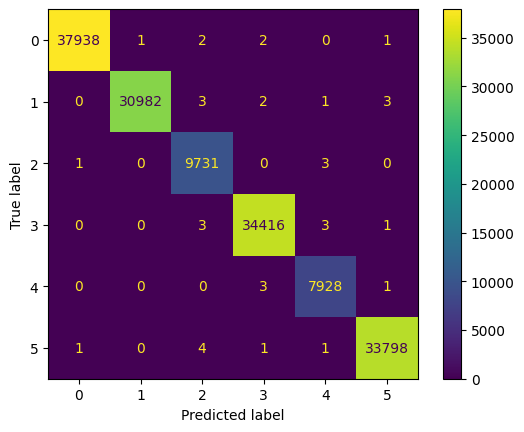

In [ ]:
#construct confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb,labels=random_search.classes_)
disp = ConfusionMatrixDisplay(cm,display_labels=random_search.classes_)
disp.plot()
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37944
           1       1.00      1.00      1.00     30991
           2       1.00      1.00      1.00      9735
           3       1.00      1.00      1.00     34423
           4       1.00      1.00      1.00      7932
           5       1.00      1.00      1.00     33805

    accuracy                           1.00    154830
   macro avg       1.00      1.00      1.00    154830
weighted avg       1.00      1.00      1.00    154830



In [ ]:
#accuracy
accuracy=accuracy_score(y_test,y_pred_xgb)
print ('The XGboost Model Accuracy:',accuracy)

The XGboost Model Accuracy: 0.9997610282245043


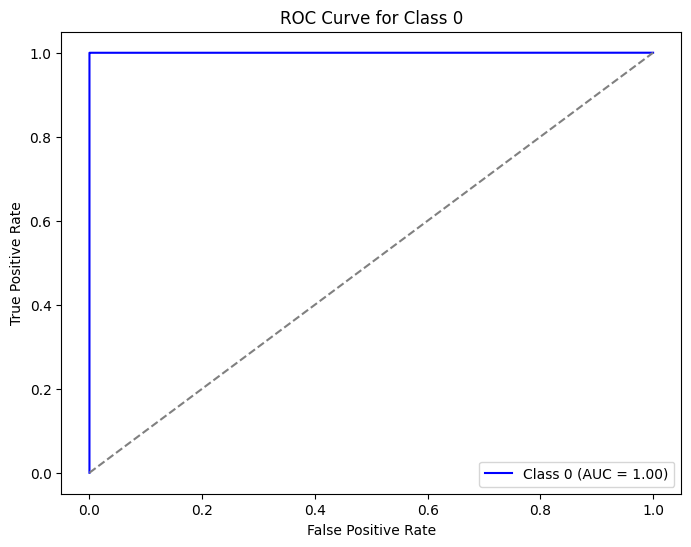

In [ ]:
y_test_bin=label_binarize(y_test,classes=random_search.classes_)
n_classes=y_test_bin.shape[1]
yproba=random_search.predict_proba(x_test_scaled)

fpr,tpr,roc_auc={},{},{}
for i in range(n_classes):
  fpr[i],tpr[i],_=roc_curve(y_test_bin[:,i],yproba[:,i])
  roc_auc[i]=auc(fpr[i],tpr[i])

fpr["micro"],tpr["micro"],_=roc_curve(y_test_bin.ravel(),yproba.ravel())
roc_auc["micro"]=auc(fpr["micro"],tpr["micro"])

plt.figure(figsize=(8, 6))
plt.plot(fpr[0], tpr[0], color='blue', label=f'Class 0 (AUC = {roc_auc[0]:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Class 0')
plt.legend(loc='lower right')
plt.show()

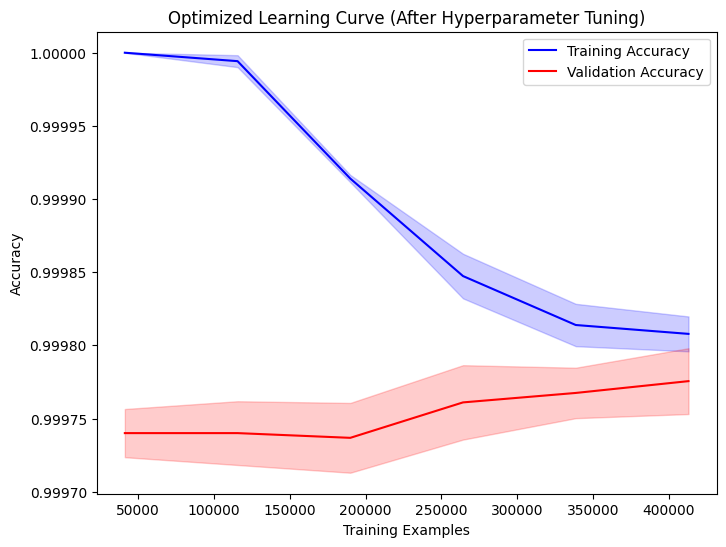

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Use the best model found from RandomizedSearchCV
best_model = random_search.best_estimator_

# Define training sizes (reduce from 10 to 6 for speed)
train_sizes = np.linspace(0.1, 1.0, 6)

# Compute learning curve
train_sizes, train_scores, test_scores = learning_curve(
    best_model, x_train_scaled, y_train,
    cv=3,  # Reduce cross-validation folds
    scoring="accuracy",
    train_sizes=train_sizes,
    n_jobs=-1
)

# Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, color='blue', label='Training Accuracy')
plt.plot(train_sizes, test_mean, color='red', label='Validation Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='red', alpha=0.2)
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Optimized Learning Curve (After Hyperparameter Tuning)')
plt.legend()
plt.show()